In [4]:
#%pip install pandas geopandas plotly scikit-learn numpy prophet matplotlib scikit-learn seaborn
import pandas as pd
import geopandas as gpd
import plotly.express as px
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import sqlite3
# Cell: Establish Database Connection
def connect_to_database(db_path="nc_energy.db"):
    """Establish connection to the SQLite database"""
    try:
        conn = sqlite3.connect(db_path)
        print(f"Successfully connected to database: {db_path}")
        return conn
    except sqlite3.Error as e:
        print(f"Error connecting to database: {e}")
        return None

# Establish connection
conn = connect_to_database()

# Verify connection by checking tables
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print("\nAvailable tables:")
    for table in tables:
        print(f"- {table[0]}")

Successfully connected to database: nc_energy.db

Available tables:
- energy_consumption
- county_populations
- energy_predictions


In [3]:
def load_and_transform_energy_data():
    # Read CSV with proper data types
    df = pd.read_csv('energy-and-utilities-linc.csv',
                     delimiter=';',
                     names=['County', 'Empty', 'Year', 'Variable', 'Value'],
                     dtype={'County': str, 'Empty': str, 'Year': str, 'Variable': str, 'Value': str})
    
    # Remove header rows and clean data
    df = df[~df['County'].isin(['Area Name', 'County'])]
    df = df[df['Value'].str.isnumeric().fillna(False)]

    # Drop empty column and convert types
    df = df.drop('Empty', axis=1)
    df['Value'] = pd.to_numeric(df['Value'])
    df['Year'] = pd.to_numeric(df['Year'])
    
    # Create pivot table
    transformed_df = pd.pivot_table(
        df,
        values='Value',
        index=['County', 'Year'],
        columns='Variable',
        aggfunc='first'
    ).reset_index()
    
    # Rename columns for clarity
    column_mapping = {
        'Occupied Housing Units Heated by Electricity': 'heated_by_electricity',
        'Occ Housing Units Heated by Gas Piped Underground': 'heated_by_gas',
        'Occupied Housing Units Heated by Fuel Oil': 'heated_by_fuel_oil',
        'Occ Housing Units Heated by Coal, Wood, Solar, or Other': 'heated_by_other',
        'Occupied Housing Units without House Heating Fuel': 'no_heating',
        'Occ Housing Units Heated by Bottled Tank or LP Gas Fuel': 'heated_by_lp_gas'
    }
    
    # Convert types and fill nulls
    transformed_df = transformed_df.rename(columns=column_mapping)
    transformed_df = transformed_df.fillna(0)
    
     # Convert to integers after cleaning
    numeric_cols = transformed_df.columns.difference(['County'])
    transformed_df[numeric_cols] = transformed_df[numeric_cols].astype(int)
    

    return transformed_df

# Cell 4: Create SQLite Database
def create_database():
    # Get transformed data
    energy_df = load_and_transform_energy_data()
    
    # Create database connection
    conn = sqlite3.connect('nc_energy.db')
    
    # Create table schema
    create_table_sql = '''
    CREATE TABLE IF NOT EXISTS energy_consumption (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    ) WITHOUT ROWID;
    '''
    conn.executescript(create_table_sql)
    energy_df.to_sql('energy_consumption', conn, if_exists='replace', index=False)
    # Insert data
    energy_df.to_sql('energy_consumption', 
                     conn, 
                     if_exists='replace', 
                     index=False,
                     dtype={
                         'County': 'TEXT',
                         'Year': 'INTEGER',
                         'heated_by_electricity': 'INTEGER',
                         'heated_by_gas': 'INTEGER',
                         'heated_by_fuel_oil': 'INTEGER',
                         'heated_by_other': 'INTEGER',
                         'no_heating': 'INTEGER',
                         'heated_by_lp_gas': 'INTEGER'
                     })
    
    return conn, energy_df

def get_county_data(conn, county_name):
    query = '''
    SELECT 
        County,
        Year,
        heated_by_electricity,
        heated_by_gas,
        heated_by_fuel_oil,
        heated_by_other,
        no_heating,
        heated_by_lp_gas
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year;
    '''
    return pd.read_sql(query, conn, params=(county_name,))

# Create database with new structure
energy_df = load_and_transform_energy_data()
print(energy_df.head())
print("\nColumns:", energy_df.columns.tolist())
print("\nData types:", energy_df.dtypes)

#Test get_county_data
conn, energy_df = create_database()
county_data = get_county_data(conn, 'Guilford County')
print(county_data.head())


Variable           County  Year  heated_by_lp_gas  heated_by_other  \
0         Alamance County  1990              4006             2541   
1         Alamance County  2000              6511             1005   
2         Alamance County  2010              6194             1243   
3         Alamance County  2015              5119             1918   
4         Alamance County  2020              4005             1101   

Variable  heated_by_gas  heated_by_electricity  heated_by_fuel_oil  no_heating  
0                 15946                  12543                7552          64  
1                 24211                  16783                2996          78  
2                 26390                  23032                2086          55  
3                 26122                  26576                1578         232  
4                 26842                  32290                 848         369  

Columns: ['County', 'Year', 'heated_by_lp_gas', 'heated_by_other', 'heated_by_gas', 'heated_

In [1]:
# Import and prepare North Carolina population data
import pandas as pd
import sqlite3
import os

# Load the census data
print("Loading historical census data...")
census_df = pd.read_csv('historic-census-2.csv')

# Clean county names if necessary
if 'AreaName' in census_df.columns:
    # Rename AreaName to County for consistency
    census_df = census_df.rename(columns={'AreaName': 'County'})

print(f"Original census data shape: {census_df.shape}")
print(census_df.head())

# Pivot the data to have years as columns
population_pivot = census_df.pivot(index='County', columns='Year', values='Population')

# Reset index to make County a regular column
county_populations = population_pivot.reset_index()

# Ensure all expected years are present as columns
expected_years = [1990, 2000, 2010, 2020]
for year in expected_years:
    if year not in county_populations.columns:
        county_populations[year] = None

# Keep only the columns we need
county_populations = county_populations[['County'] + expected_years]

# Rename columns to be more descriptive
county_populations.columns = ['County', 'Population_1990', 'Population_2000', 'Population_2010', 'Population_2020']

print(f"Transformed county population data shape: {county_populations.shape}")
print(county_populations.head())

# Connect to SQLite database
db_path = 'nc_energy.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Create a new table for county populations
print("Creating county_populations table in database...")
cursor.execute('''
DROP TABLE IF EXISTS county_populations
''')

cursor.execute('''
CREATE TABLE county_populations (
    County TEXT PRIMARY KEY,
    Population_1990 INTEGER,
    Population_2000 INTEGER,
    Population_2010 INTEGER,
    Population_2020 INTEGER
)
''')

# Insert data into the table
county_populations.to_sql('county_populations', conn, if_exists='replace', index=False)

# Verify the data was inserted correctly
print("Verifying data insertion...")
verification = pd.read_sql_query("SELECT * FROM county_populations LIMIT 5", conn)
print(verification)

# Count the rows in the table
row_count = pd.read_sql_query("SELECT COUNT(*) FROM county_populations", conn).iloc[0, 0]
print(f"Total counties in population table: {row_count}")

# Close connection
conn.close()

print("County population data successfully loaded into the database!")

Loading historical census data...
Original census data shape: (400, 3)
      County  Year  Population
0  Alexander  2010       37198
1     Bertie  2010       21282
2  Brunswick  2020      136693
3   Caldwell  2000       77708
4     Camden  1990        5904
Transformed county population data shape: (100, 5)
      County  Population_1990  Population_2000  Population_2010  \
0   Alamance           108213           130800           151131   
1  Alexander            27544            33603            37198   
2  Alleghany             9590            10680            11155   
3      Anson            23474            25275            26948   
4       Ashe            22209            24384            27281   

   Population_2020  
0           171415  
1            36444  
2            10888  
3            22055  
4            26577  
Creating county_populations table in database...
Verifying data insertion...
      County  Population_1990  Population_2000  Population_2010  \
0   Alamance       

In [6]:
# Fix county name format

def standardize_county_names(conn):
    """
    Standardize county names between energy_consumption and county_populations tables
    to ensure they can be properly joined
    """
    print("Standardizing county names in population data...")
    
    # Get county names from energy_consumption
    energy_counties = pd.read_sql_query("SELECT DISTINCT County FROM energy_consumption", conn)
    energy_counties['BaseCounty'] = energy_counties['County'].str.replace(' County', '')
    
    # Get county names from county_populations
    pop_counties = pd.read_sql_query("SELECT DISTINCT County FROM county_populations", conn)
    
    # Check format differences
    print(f"Energy counties (first 5): {energy_counties['County'].head().tolist()}")
    print(f"Population counties (first 5): {pop_counties['County'].head().tolist()}")
    
    # If population counties don't end with " County", add it to match energy_consumption
    needs_update = False
    for _, energy_row in energy_counties.iterrows():
        energy_county = energy_row['County']
        base_county = energy_row['BaseCounty']
        
        # Check if we need to add "County" suffix
        if energy_county.endswith(' County') and base_county in pop_counties['County'].values:
            needs_update = True
            break
    
    if needs_update:
        print("County name format mismatch detected. Updating population table...")
        
        # Get current population data
        pop_data = pd.read_sql_query("SELECT * FROM county_populations", conn)
        
        # Create a mapping between existing county names and standardized names
        county_mapping = {}
        
        for idx, pop_row in pop_data.iterrows():
            pop_county = pop_row['County']
            
            # Find matching energy county
            for _, energy_row in energy_counties.iterrows():
                energy_county = energy_row['County']
                base_county = energy_row['BaseCounty']
                
                # If the base county name matches, use the energy county name format
                if pop_county == base_county or pop_county.lower() == base_county.lower():
                    county_mapping[pop_county] = energy_county
                    break
        
        # Update population data with standardized county names
        new_pop_data = pop_data.copy()
        for old_name, new_name in county_mapping.items():
            new_pop_data.loc[new_pop_data['County'] == old_name, 'County'] = new_name
            
        # Display changes
        changes = [(old, new) for old, new in county_mapping.items() if old != new]
        if changes:
            print("County name changes:")
            for old, new in changes:
                print(f"  {old} -> {new}")
                
            # Drop existing table and create new one
            cursor = conn.cursor()
            cursor.execute("DROP TABLE IF EXISTS county_populations")
            conn.commit()
            
            # Write updated data back to database
            new_pop_data.to_sql('county_populations', conn, if_exists='replace', index=False)
            print(f"Updated {len(changes)} county names in population table")
        else:
            print("No county name updates needed")
    else:
        print("County name formats appear to be consistent")
        
    # Verify the join works correctly
    test_query = """
    SELECT e.County as EnergyCounty, p.County as PopCounty
    FROM energy_consumption e
    JOIN county_populations p ON e.County = p.County
    GROUP BY e.County
    """
    test_result = pd.read_sql_query(test_query, conn)
    print(f"Successfully joined {len(test_result)} counties between energy and population data")
    
    return len(test_result)

# Run the function to standardize county names
joined_count = standardize_county_names(conn)
print(f"Ready to generate predictions with {joined_count} counties that have population data")

Standardizing county names in population data...
Energy counties (first 5): ['Alamance County', 'Alexander County', 'Alleghany County', 'Anson County', 'Ashe County']
Population counties (first 5): ['Alamance', 'Alexander', 'Alleghany', 'Anson', 'Ashe']
County name format mismatch detected. Updating population table...
County name changes:
  Alamance -> Alamance County
  Alexander -> Alexander County
  Alleghany -> Alleghany County
  Anson -> Anson County
  Ashe -> Ashe County
  Avery -> Avery County
  Beaufort -> Beaufort County
  Bertie -> Bertie County
  Bladen -> Bladen County
  Brunswick -> Brunswick County
  Buncombe -> Buncombe County
  Burke -> Burke County
  Cabarrus -> Cabarrus County
  Caldwell -> Caldwell County
  Camden -> Camden County
  Carteret -> Carteret County
  Caswell -> Caswell County
  Catawba -> Catawba County
  Chatham -> Chatham County
  Cherokee -> Cherokee County
  Chowan -> Chowan County
  Clay -> Clay County
  Cleveland -> Cleveland County
  Columbus -> Co

In [11]:
# Cell 4: Query Functions
#Specific County Data
def get_county_data(conn, county_name):
    query = '''
    SELECT * FROM energy_consumption 
    WHERE county = ? 
    ORDER BY Year
    '''
    return pd.read_sql_query(query, conn, params=[county_name])

#County List
def get_county_list(conn):
    query = '''
    SELECT DISTINCT county FROM energy_consumption
    '''
    return pd.read_sql_query(query, conn)

#Select largest counties
def get_largest_counties(conn, n=5):
    query = '''
    SELECT county, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY county
    ORDER BY total_energy DESC
    LIMIT ?
    '''
    return pd.read_sql_query(query, conn, params=[n])

#Select total energy by year
def get_total_energy_by_year(conn):
    query = '''
    SELECT year, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY year
    '''
    return pd.read_sql_query(query, conn)

#Print the returned queries
print(get_county_list(conn))
print(get_county_data(conn, 'Guilford County').head())

              County
0    Alamance County
1   Alexander County
2   Alleghany County
3       Anson County
4        Ashe County
..               ...
95      Wayne County
96     Wilkes County
97     Wilson County
98     Yadkin County
99     Yancey County

[100 rows x 1 columns]
            County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0  Guilford County  1990              4291             5438          48770   
1  Guilford County  2000              7941             2034          76608   
2  Guilford County  2010              7944             1771          85699   
3  Guilford County  2015              6445             1999          82119   
4  Guilford County  2020              6132             1926          85206   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  57535               21482         190  
1                  71024               10715         345  
2                  87088                6580         479  
3                 1

In [10]:
# Cell: ML Predictions with Prophet (Enhanced with Population Data)
def create_prophet_predictions(conn, county_name, heating_type):
    """
    Generate predictions for a county and heating type using population growth to
    inform housing demand and maintain realistic energy type distributions.
    """
    # Get base county name (without 'County' suffix if present)
    base_county_name = county_name.replace(' County', '')
    
    # First, get ALL energy types for this county to understand distribution patterns
    all_energy_query = """
    SELECT e.Year, 
           e.heated_by_electricity, e.heated_by_gas, e.heated_by_fuel_oil, 
           e.heated_by_other, e.no_heating, e.heated_by_lp_gas
    FROM energy_consumption e
    WHERE e.County = ?
    ORDER BY e.Year
    """
    energy_df = pd.read_sql_query(all_energy_query, conn, params=[county_name])
    
    if energy_df.empty:
        print(f"No energy data found for {county_name}")
        return None, None
    
    # Get population data separately for better control
    pop_query = """
    SELECT County, Population_1990, Population_2000, Population_2010, Population_2020
    FROM county_populations
    WHERE County = ? OR County = ? OR County LIKE ?
    """
    pop_df = pd.read_sql_query(pop_query, conn, 
                             params=[county_name, base_county_name, f"{base_county_name}%"])
    
    if pop_df.empty:
        # Try a more fuzzy approach to find closest match
        all_counties = pd.read_sql_query("SELECT County FROM county_populations", conn)
        
        for idx, pop_county in all_counties.iterrows():
            if base_county_name.lower() in pop_county['County'].lower() or \
               pop_county['County'].lower() in base_county_name.lower():
                print(f"Found potential match: {pop_county['County']} for {county_name}")
                pop_df = pd.read_sql_query(
                    "SELECT * FROM county_populations WHERE County = ?", 
                    conn, params=[pop_county['County']]
                )
                break
    
    # Create population dictionary by year
    population_by_year = {}
    
    if not pop_df.empty:
        # Extract population values from population table
        if not pd.isna(pop_df['Population_1990'].iloc[0]):
            population_by_year[1990] = float(pop_df['Population_1990'].iloc[0])
        if not pd.isna(pop_df['Population_2000'].iloc[0]):
            population_by_year[2000] = float(pop_df['Population_2000'].iloc[0])
        if not pd.isna(pop_df['Population_2010'].iloc[0]):
            population_by_year[2010] = float(pop_df['Population_2010'].iloc[0])
        if not pd.isna(pop_df['Population_2020'].iloc[0]):
            population_by_year[2020] = float(pop_df['Population_2020'].iloc[0])
    
    # If no population data was found, create synthetic population
    if not population_by_year:
        print(f"No population data found for {county_name}, using synthetic population")
        # Calculate total housing units for each year
        energy_df['total_housing'] = energy_df[['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                                             'heated_by_other', 'no_heating', 'heated_by_lp_gas']].sum(axis=1)
        
        # Estimate population based on housing units (assume ~2.5 people per housing unit)
        for idx, row in energy_df.iterrows():
            population_by_year[row['Year']] = row['total_housing'] * 2.5
    
    # Add population column to energy_df
    energy_df['Population'] = energy_df['Year'].map(population_by_year)
    
    # Fill any remaining NaN values with interpolation and extrapolation
    # First sort by year to ensure proper interpolation
    energy_df = energy_df.sort_values('Year')
    
    # Use interpolation to fill gaps
    energy_df['Population'] = energy_df['Population'].interpolate(method='linear')
    
    # Handle extrapolation for any missing years at the beginning or end
    # Forward fill for early years
    energy_df['Population'] = energy_df['Population'].ffill()
    # Backward fill for later years
    energy_df['Population'] = energy_df['Population'].bfill()
    
    # Calculate total housing units
    energy_df['total_housing'] = energy_df[['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                                         'heated_by_other', 'no_heating', 'heated_by_lp_gas']].sum(axis=1)
    
    # Calculate housing units per capita ratio
    energy_df['housing_per_capita'] = energy_df['total_housing'] / energy_df['Population']
    
    # Replace any infinite values (from division by zero) with the median
    energy_df['housing_per_capita'] = energy_df['housing_per_capita'].replace([np.inf, -np.inf], np.nan)
    energy_df['housing_per_capita'] = energy_df['housing_per_capita'].fillna(energy_df['housing_per_capita'].median())
    
    # Calculate the percentage of each energy type
    for col in ['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                'heated_by_other', 'no_heating', 'heated_by_lp_gas']:
        energy_df[f'{col}_pct'] = energy_df[col] / energy_df['total_housing']
    
    # Fill potential NaN values with median
    for col in [f'{c}_pct' for c in ['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                                     'heated_by_other', 'no_heating', 'heated_by_lp_gas']]:
        energy_df[col] = energy_df[col].fillna(energy_df[col].median())
    
    # Project future population using robust growth rates
    pop_df = energy_df[['Year', 'Population']].dropna()
    
    # Analyze population trends
    if len(pop_df) >= 2:
        # Calculate average annual growth rate over all available periods
        pop_df = pop_df.sort_values('Year')
        first_year = pop_df['Year'].min()
        last_year = pop_df['Year'].max()
        first_pop = pop_df.loc[pop_df['Year'] == first_year, 'Population'].iloc[0]
        last_pop = pop_df.loc[pop_df['Year'] == last_year, 'Population'].iloc[0]
        years_diff = last_year - first_year
        
        if years_diff > 0 and first_pop > 0:
            # Calculate compound annual growth rate
            annual_growth_rate = (last_pop / first_pop) ** (1 / years_diff) - 1
            
            # Ensure growth rate is realistic (between -0.5% and 3% per year)
            annual_growth_rate = max(-0.005, min(annual_growth_rate, 0.03))
            
            # Apply growth rate to project future population
            latest_pop = pop_df.loc[pop_df['Year'] == pop_df['Year'].max(), 'Population'].iloc[0]
            projected_populations = np.array([
                latest_pop * (1 + annual_growth_rate) ** (i + 1) for i in range(4)
            ])
        else:
            # Fallback to state average growth
            latest_pop = pop_df.loc[pop_df['Year'] == pop_df['Year'].max(), 'Population'].iloc[0]
            projected_populations = np.array([
                latest_pop * 1.05,  # 2025: 5% growth from latest
                latest_pop * 1.10,  # 2030: 10% growth
                latest_pop * 1.15,  # 2035: 15% growth
                latest_pop * 1.20   # 2040: 20% growth
            ])
    else:
        # Without enough population data, use state average growth rates
        last_known_year = energy_df['Year'].max()
        last_known_pop = energy_df.loc[energy_df['Year'] == last_known_year, 'Population'].iloc[0]
        
        # Estimate growth rates based on NC state average (approx 1% per year)
        projected_populations = np.array([
            last_known_pop * 1.05,  # 2025
            last_known_pop * 1.10,  # 2030
            last_known_pop * 1.15,  # 2035
            last_known_pop * 1.20   # 2040
        ])
    
    # Get most recent energy type distribution (percentages)
    latest_year = energy_df['Year'].max()
    latest_data = energy_df[energy_df['Year'] == latest_year]
    
    # Get most recent housing per capita ratio
    latest_housing_per_capita = latest_data['housing_per_capita'].iloc[0]
    
    # Create future dataframe with projected data
    future_data = []
    future_years = [2025, 2030, 2035, 2040]
    
    # Analyze historical trends for each energy type
    energy_trends = {}
    
    # For each energy type, analyze its trend over time
    for col in ['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                'heated_by_other', 'no_heating', 'heated_by_lp_gas']:
        pct_col = f'{col}_pct'
        
        # Check if the energy type has a strong trend of decline
        if len(energy_df) >= 3:  # Need at least 3 data points for trend
            X_trend = energy_df['Year'].values.reshape(-1, 1)
            y_trend = energy_df[pct_col].values
            
            trend_model = LinearRegression()
            trend_model.fit(X_trend, y_trend)
            
            # Predict 2040 percentage based on trend
            predicted_2040_pct = trend_model.predict([[2040]])[0]
            
            # Calculate current trajectory
            latest_pct = latest_data[pct_col].iloc[0]
            
            # Set a minimum percentage floor for each energy type to prevent zeroing out
            min_floor = 0.001  # 0.1% minimum for all types
            
            # Special handling for heating types that shouldn't go to zero but do decline
            if col in ['heated_by_fuel_oil', 'heated_by_other']:
                # Higher floor for these types (0.5%)
                min_floor = 0.005
                
                # If trend shows severe decline but current percentage is significant
                if predicted_2040_pct < min_floor and latest_pct > 0.01:
                    # Use a more conservative asymptotic decline model
                    # This ensures the value approaches the floor but never reaches zero
                    energy_trends[col] = {
                        'model': 'asymptotic',
                        'current': latest_pct,
                        'floor': min_floor
                    }
                    continue
            
            # Store linear trend model
            energy_trends[col] = {
                'model': 'linear',
                'slope': trend_model.coef_[0],
                'intercept': trend_model.intercept_,
                'min_floor': min_floor
            }
        else:
            # Not enough data for trend, maintain latest percentage with slight variation
            latest_pct = latest_data[pct_col].iloc[0]
            energy_trends[col] = {
                'model': 'static',
                'value': latest_pct,
                'min_floor': 0.001
            }
    
    # Generate future projections
    for i, year in enumerate(future_years):
        future_row = {'Year': year, 'Population': projected_populations[i]}
        
        # Calculate expected total housing units based on population and housing per capita
        future_row['total_housing'] = future_row['Population'] * latest_housing_per_capita
        
        # First pass - calculate raw projections based on models
        raw_projections = {}
        
        for col in ['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                    'heated_by_other', 'no_heating', 'heated_by_lp_gas']:
            trend_info = energy_trends[col]
            
            if trend_info['model'] == 'linear':
                # Apply linear trend model with floor
                projected_pct = trend_info['slope'] * year + trend_info['intercept']
                projected_pct = max(trend_info['min_floor'], projected_pct)
                projected_pct = min(projected_pct, 0.99)  # Cap at 99%
                
            elif trend_info['model'] == 'asymptotic':
                # Apply asymptotic decline model that never reaches zero
                years_from_latest = year - latest_year
                decay_factor = 0.85 ** (years_from_latest / 5)  # 15% reduction every 5 years
                
                # Equation ensures value approaches floor asymptotically
                projected_pct = trend_info['floor'] + (trend_info['current'] - trend_info['floor']) * decay_factor
                
            else:  # 'static'
                # Maintain latest percentage with small random variation
                base_pct = trend_info['value']
                variation = 0.05  # 5% variation
                years_ahead = (i + 1) / 4  # 0.25 to 1.0 scaling factor
                
                # Slightly more electricity and gas over time (reflecting general trends)
                if col in ['heated_by_electricity', 'heated_by_gas']:
                    projected_pct = base_pct * (1 + variation * years_ahead)
                elif col in ['heated_by_fuel_oil', 'heated_by_other']:
                    # Gradual decline for fuel oil and other
                    projected_pct = base_pct * (1 - variation * years_ahead)
                    projected_pct = max(projected_pct, trend_info['min_floor'])
                else:
                    # Other types remain mostly stable
                    projected_pct = base_pct
            
            # Store raw projection
            raw_projections[col] = projected_pct
        
        # Second pass - normalize percentages to ensure they sum to 1
        total_pct = sum(raw_projections.values())
        
        if total_pct > 0:
            # Normalize percentages
            normalized_projections = {col: pct / total_pct for col, pct in raw_projections.items()}
            
            # Calculate final housing units for each type
            for col, pct in normalized_projections.items():
                future_row[col] = int(round(future_row['total_housing'] * pct))
        else:
            # Failsafe - if all percentages somehow ended up as 0
            # Distribute using latest proportions
            for col in ['heated_by_electricity', 'heated_by_gas', 'heated_by_fuel_oil', 
                       'heated_by_other', 'no_heating', 'heated_by_lp_gas']:
                pct_col = f'{col}_pct'
                future_row[col] = int(round(future_row['total_housing'] * latest_data[pct_col].iloc[0]))
        
        future_data.append(future_row)
    
    # Create future DataFrame
    future_df = pd.DataFrame(future_data)
    
    # Get training data for Prophet - just the selected heating type
    df = pd.DataFrame({
        'Year': energy_df['Year'],
        heating_type: energy_df[heating_type],
        'Population': energy_df['Population']
    })
    
    # Now prepare for Prophet model
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['Year'].astype(str)),
        'y': df[heating_type],
        'population': df['Population']
    })
    
    # Double check for NaN values in the prophet_df
    if prophet_df.isnull().any().any():
        print(f"Warning: Found NaN values in prophet_df for {county_name}, {heating_type}")
        # Fill NaN values in population column
        prophet_df['population'] = prophet_df['population'].interpolate().ffill().bfill()
        # Fill NaN values in y column with 0
        prophet_df['y'] = prophet_df['y'].fillna(0)
    
    # Create Prophet model
    model = Prophet(
        yearly_seasonality=False,
        growth='linear',
        changepoint_prior_scale=0.05  # More conservative to prevent overfit
    )
    
    # Add population as a regressor
    model.add_regressor('population')
    
    # Fit the model
    try:
        model.fit(prophet_df)
    except Exception as e:
        print(f"Error fitting Prophet model for {county_name}, {heating_type}: {e}")
        # Return distribution-based predictions as fallback
        predictions = pd.DataFrame({
            'County': county_name,
            'Year': future_df['Year'],
            heating_type: future_df[heating_type]
        })
        return predictions[['County', 'Year', heating_type]], None
    
    # Create future dataframe for Prophet
    prophet_future = pd.DataFrame({
        'ds': pd.to_datetime(future_df['Year'].astype(str)),
        'population': future_df['Population']
    })
    
    # Make prediction with Prophet
    forecast = model.predict(prophet_future)
    
    # Compare Prophet's predictions with our distribution-based predictions
    prophet_predictions = forecast['yhat'].values
    distribution_predictions = future_df[heating_type].values
    
    # Blend the predictions with more weight to distribution for declining energy types
    # For 'heated_by_fuel_oil' and 'heated_by_other', trust our distribution model more
    if heating_type in ['heated_by_fuel_oil', 'heated_by_other']:
        # Use 30% Prophet, 70% distribution for these types to prevent unrealistic zeros
        blended_predictions = np.round(0.3 * prophet_predictions + 0.7 * distribution_predictions).astype(int)
    else:
        # Standard 50/50 blend for other types
        blended_predictions = np.round(0.5 * prophet_predictions + 0.5 * distribution_predictions).astype(int)
    
    # Apply final validation rules - enforce minimums for certain types
    if heating_type in ['heated_by_fuel_oil', 'heated_by_other']:
        # Find last non-zero historical value
        historical_values = df[heating_type].values
        last_nonzero = max(historical_values[-1], 1) if any(historical_values > 0) else 1
        
        # Create declining floor that never reaches zero
        # At least 20% of last value by 2025, 10% by 2030, 5% by 2035, 2% by 2040
        floor_multipliers = [0.20, 0.10, 0.05, 0.02]
        minimum_values = [max(int(last_nonzero * m), 1) for m in floor_multipliers]
        
        # Apply the minimum values
        blended_predictions = np.maximum(blended_predictions, minimum_values)
    
    # Ensure predictions are non-negative
    blended_predictions = np.maximum(blended_predictions, 0)
    
    # Create prediction DataFrame for database
    predictions = pd.DataFrame({
        'County': county_name,
        'Year': future_df['Year'],
        heating_type: blended_predictions
    })
    
    print(f"Generated {len(predictions)} predictions for {county_name}, {heating_type}")
    print(f"  Prophet: {prophet_predictions.astype(int)}")
    print(f"  Distribution-based: {distribution_predictions}")
    print(f"  Blended (final): {blended_predictions}")
    
    return predictions[['County', 'Year', heating_type]], model

# Function to generate predictions for all counties and heating types
def generate_and_store_predictions(conn):
    """Generate predictions for all counties and all heating types using population data"""
    # Get all counties
    counties = pd.read_sql_query("SELECT DISTINCT County FROM energy_consumption", conn)
    
    # Get all heating types (excluding County and Year columns)
    heating_types = [col for col in pd.read_sql_query("SELECT * FROM energy_consumption LIMIT 1", conn).columns 
                    if col not in ['County', 'Year']]
    
    # Create predictions table if it doesn't exist
    create_predictions_table = """
    CREATE TABLE IF NOT EXISTS energy_predictions (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    )
    """
    conn.execute("DROP TABLE IF EXISTS energy_predictions")
    conn.execute(create_predictions_table)
    
    # Generate predictions for each county and heating type
    all_predictions = []
    
    for _, county_row in counties.iterrows():
        county = county_row['County']
        print(f"Generating predictions for {county}...")
        
        county_predictions = {}
        for heating_type in heating_types:
            try:
                predictions, _ = create_prophet_predictions(conn, county, heating_type)
                if predictions is not None:
                    county_predictions[heating_type] = predictions[heating_type].values
                else:
                    # Fallback to simple trend if prediction fails
                    print(f"Using fallback prediction for {county}, {heating_type}")
                    county_data = pd.read_sql_query(
                        f"SELECT Year, {heating_type} FROM energy_consumption WHERE County = ? ORDER BY Year",
                        conn, params=[county]
                    )
                    if not county_data.empty:
                        latest_value = county_data[heating_type].iloc[-1]
                        # Simple trend: maintain latest value with slight growth
                        county_predictions[heating_type] = np.array([
                            max(0, int(latest_value * 1.02)),
                            max(0, int(latest_value * 1.04)),
                            max(0, int(latest_value * 1.06)),
                            max(0, int(latest_value * 1.08))
                        ])
                    else:
                        county_predictions[heating_type] = np.array([0, 0, 0, 0])
            except Exception as e:
                print(f"Error generating predictions for {county}, {heating_type}: {e}")
                # Fallback to zeros if completely failed
                county_predictions[heating_type] = np.array([0, 0, 0, 0])
        
        # Combine predictions for all heating types
        for year_idx, year in enumerate(range(2025, 2041, 5)):
            prediction_row = {
                'County': county,
                'Year': year
            }
            for heating_type in heating_types:
                if heating_type in county_predictions and county_predictions[heating_type] is not None:
                    if year_idx < len(county_predictions[heating_type]):
                        prediction_row[heating_type] = int(county_predictions[heating_type][year_idx])
                    else:
                        prediction_row[heating_type] = 0
                else:
                    prediction_row[heating_type] = 0
            
            all_predictions.append(prediction_row)
    
    # Convert to DataFrame and store in database
    predictions_df = pd.DataFrame(all_predictions)
    predictions_df.to_sql('energy_predictions', conn, if_exists='replace', index=False)
    
    print("Predictions generated and stored in database.")
    return predictions_df

# Generate and store predictions
predictions_df = generate_and_store_predictions(conn)

# Display sample of predictions
print("\nSample of generated predictions:")
print(predictions_df.head())

# Verify data in database
print("\nVerifying data in database:")
print(pd.read_sql_query("SELECT * FROM energy_predictions LIMIT 5", conn))

Generating predictions for Alamance County...


17:23:32 - cmdstanpy - INFO - Chain [1] start processing
17:23:32 - cmdstanpy - INFO - Chain [1] done processing


Generated 4 predictions for Alamance County, heated_by_lp_gas
  Prophet: [  -287  -5403 -10492 -15553]
  Distribution-based: [4579 4146 3724 3311]
  Blended (final): [2146    0    0    0]


17:23:33 - cmdstanpy - INFO - Chain [1] start processing
17:23:33 - cmdstanpy - INFO - Chain [1] done processing
17:23:33 - cmdstanpy - INFO - Chain [1] start processing


Generated 4 predictions for Alamance County, heated_by_other
  Prophet: [2418 3580 4735 5884]
  Distribution-based: [956 851 762 687]
  Blended (final): [1395 1670 1954 2246]


...

Generated 4 predictions for Yancey County, heated_by_lp_gas
  Prophet: [1379 1536 1694 1851]
  Distribution-based: [1411 1593 1778 1965]
  Blended (final): [1395 1565 1736 1908]
Generated 4 predictions for Yancey County, heated_by_other
  Prophet: [1567 1744 1922 2098]
  Distribution-based: [1138 1077 1015  952]
  Blended (final): [1267 1277 1287 1296]


17:26:21 - cmdstanpy - INFO - Chain [1] start processing
17:26:21 - cmdstanpy - INFO - Chain [1] done processing
17:26:21 - cmdstanpy - INFO - Chain [1] start processing
17:26:21 - cmdstanpy - INFO - Chain [1] done processing


Generated 4 predictions for Yancey County, heated_by_gas
  Prophet: [361 436 511 587]
  Distribution-based: [324 379 434 490]
  Blended (final): [343 408 473 539]
Generated 4 predictions for Yancey County, heated_by_electricity
  Prophet: [2649 3079 3509 3939]
  Distribution-based: [2441 2759 3081 3406]
  Blended (final): [2545 2919 3295 3673]


17:26:21 - cmdstanpy - INFO - Chain [1] start processing
17:26:21 - cmdstanpy - INFO - Chain [1] done processing
17:26:22 - cmdstanpy - INFO - Chain [1] start processing
17:26:22 - cmdstanpy - INFO - Chain [1] done processing


Generated 4 predictions for Yancey County, heated_by_fuel_oil
  Prophet: [ 1537   659  -217 -1093]
  Distribution-based: [2182 1731 1275  813]
  Blended (final): [1989 1410  827  241]
Generated 4 predictions for Yancey County, no_heating
  Prophet: [17 20 24 27]
  Distribution-based: [15 17 19 21]
  Blended (final): [16 19 22 24]
Predictions generated and stored in database.

Sample of generated predictions:
             County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0   Alamance County  2025              2146             1395          16694   
1   Alamance County  2030                 0             1670           6098   
2   Alamance County  2035                 0             1954              0   
3   Alamance County  2040                 0             2246              0   
4  Alexander County  2025               711              562            534   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  39412                3979         3

1. Basic verification of the prediction data
   total_rows  county_count  min_year  max_year
0         400           100      2025      2040

2. Sample of prediction data for a few counties
                County  Year  heated_by_electricity  heated_by_gas  \
0      Guilford County  2025                 123273          73633   
1      Guilford County  2030                 135797          61367   
2      Guilford County  2035                 148279          49190   
3      Guilford County  2040                 160722          37104   
4   Mecklenburg County  2025                 203813         241952   
5   Mecklenburg County  2030                 211038         266983   
6   Mecklenburg County  2035                 218359         291998   
7   Mecklenburg County  2040                 225780         316993   
8          Wake County  2025                 229852         192510   
9          Wake County  2030                 242862         208648   
10         Wake County  2035            

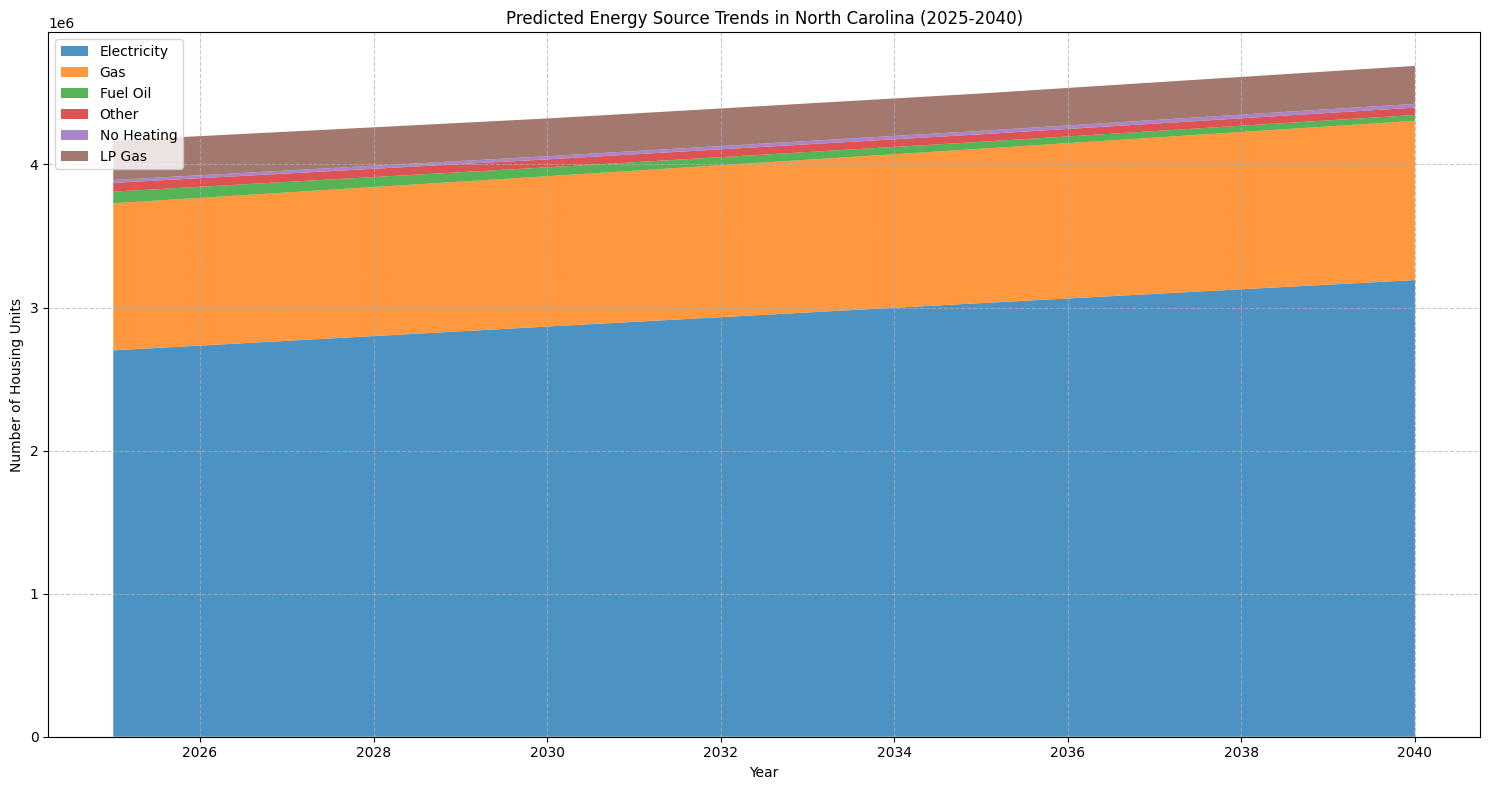


9. Correlation between population and electricity usage
Sample county formats in tables:
           table_name            County  count
0  energy_predictions   Alamance County      4
1  energy_predictions  Alexander County      4
2  energy_predictions  Alleghany County      4
3  energy_predictions      Anson County      4
4  energy_predictions       Ashe County      4
5  energy_predictions      Avery County      4
6  energy_predictions   Beaufort County      4
7  energy_predictions     Bertie County      4
8  energy_predictions     Bladen County      4
9  energy_predictions  Brunswick County      4
Successfully matched 0 counties with population data
Empty DataFrame
Columns: [County, Year, heated_by_electricity, estimated_population]
Index: []
No matching county population data found. Check county name formats in both tables.


In [ ]:
# Queries to check energy prediction data in the database

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
conn = sqlite3.connect('nc_energy.db')

print("1. Basic verification of the prediction data")
basic_check = pd.read_sql_query("""
SELECT COUNT(*) AS total_rows, 
       COUNT(DISTINCT County) AS county_count,
       MIN(Year) AS min_year,
       MAX(Year) AS max_year
FROM energy_predictions
""", conn)
print(basic_check)

print("\n2. Sample of prediction data for a few counties")
sample_data = pd.read_sql_query("""
SELECT County, Year, 
       heated_by_electricity, heated_by_gas, 
       heated_by_fuel_oil, heated_by_other, 
       no_heating, heated_by_lp_gas
FROM energy_predictions
WHERE County IN ('Wake County', 'Guilford County', 'Mecklenburg County')
ORDER BY County, Year
""", conn)
print(sample_data)

print("\n3. Check for negative values (should be none)")
negative_check = pd.read_sql_query("""
SELECT County, Year,
       MIN(heated_by_electricity) AS min_electricity,
       MIN(heated_by_gas) AS min_gas,
       MIN(heated_by_fuel_oil) AS min_fuel_oil,
       MIN(heated_by_other) AS min_other,
       MIN(no_heating) AS min_no_heating,
       MIN(heated_by_lp_gas) AS min_lp_gas
FROM energy_predictions
GROUP BY County
HAVING min_electricity < 0 OR min_gas < 0 OR min_fuel_oil < 0 OR 
       min_other < 0 OR min_no_heating < 0 OR min_lp_gas < 0
""", conn)
print(f"Counties with negative values: {len(negative_check)}")
if not negative_check.empty:
    print(negative_check)

print("\n4. Total energy consumption by year (all counties)")
yearly_totals = pd.read_sql_query("""
SELECT Year,
       SUM(heated_by_electricity) AS total_electricity,
       SUM(heated_by_gas) AS total_gas,
       SUM(heated_by_fuel_oil) AS total_fuel_oil,
       SUM(heated_by_other) AS total_other,
       SUM(no_heating) AS total_no_heating,
       SUM(heated_by_lp_gas) AS total_lp_gas,
       SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + 
           heated_by_other + no_heating + heated_by_lp_gas) AS grand_total
FROM energy_predictions
GROUP BY Year
ORDER BY Year
""", conn)
print(yearly_totals)

print("\n5. Counties with highest predicted growth in electricity usage (2025-2040)")
growth_analysis = pd.read_sql_query("""
WITH CountyGrowth AS (
    SELECT County,
           MAX(CASE WHEN Year = 2025 THEN heated_by_electricity ELSE 0 END) AS start_value,
           MAX(CASE WHEN Year = 2040 THEN heated_by_electricity ELSE 0 END) AS end_value
    FROM energy_predictions
    WHERE Year IN (2025, 2040)
    GROUP BY County
)
SELECT County, 
       start_value, 
       end_value,
       end_value - start_value AS absolute_growth,
       CASE 
           WHEN start_value > 0 THEN ROUND((end_value - start_value) * 100.0 / start_value, 2)
           ELSE 0
       END AS percentage_growth
FROM CountyGrowth
ORDER BY absolute_growth DESC
LIMIT 10
""", conn)
print(growth_analysis)

print("\n6. Compare predictions with historical data for 2020")
comparison_2020 = pd.read_sql_query("""
SELECT h.County, 
       h.heated_by_electricity AS hist_electricity,
       p.heated_by_electricity AS pred_electricity,
       ROUND((p.heated_by_electricity - h.heated_by_electricity) * 100.0 / h.heated_by_electricity, 2) AS pct_diff_electricity,
       h.heated_by_gas AS hist_gas,
       p.heated_by_gas AS pred_gas,
       ROUND((p.heated_by_gas - h.heated_by_gas) * 100.0 / NULLIF(h.heated_by_gas, 0), 2) AS pct_diff_gas
FROM energy_consumption h
JOIN energy_predictions p ON h.County = p.County
WHERE h.Year = 2020 AND p.Year = 2025
ORDER BY pct_diff_electricity DESC
LIMIT 15
""", conn)
print(comparison_2020)

print("\n7. Energy mix in 2040 vs 2025 (percentage of each type)")
energy_mix = pd.read_sql_query("""
WITH YearlyTotals AS (
    SELECT Year,
           SUM(heated_by_electricity) AS total_electricity,
           SUM(heated_by_gas) AS total_gas,
           SUM(heated_by_fuel_oil) AS total_fuel_oil,
           SUM(heated_by_other) AS total_other,
           SUM(no_heating) AS total_no_heating,
           SUM(heated_by_lp_gas) AS total_lp_gas,
           SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + 
               heated_by_other + no_heating + heated_by_lp_gas) AS grand_total
    FROM energy_predictions
    WHERE Year IN (2025, 2040)
    GROUP BY Year
)
SELECT Year,
       ROUND(total_electricity * 100.0 / grand_total, 2) AS pct_electricity,
       ROUND(total_gas * 100.0 / grand_total, 2) AS pct_gas,
       ROUND(total_fuel_oil * 100.0 / grand_total, 2) AS pct_fuel_oil,
       ROUND(total_other * 100.0 / grand_total, 2) AS pct_other,
       ROUND(total_no_heating * 100.0 / grand_total, 2) AS pct_no_heating,
       ROUND(total_lp_gas * 100.0 / grand_total, 2) AS pct_lp_gas
FROM YearlyTotals
ORDER BY Year
""", conn)
print(energy_mix)

print("\n8. Outlier detection - counties with unusually high growth rates")
outliers = pd.read_sql_query("""
WITH GrowthRates AS (
    SELECT County, 
           heated_by_electricity,
           Year,
           LAG(heated_by_electricity) OVER (PARTITION BY County ORDER BY Year) AS prev_value,
           Year - LAG(Year) OVER (PARTITION BY County ORDER BY Year) AS year_diff
    FROM energy_predictions
    ORDER BY County, Year
),
AnnualGrowth AS (
    SELECT County,
           Year,
           heated_by_electricity,
           prev_value,
           CASE 
               WHEN year_diff > 0 AND prev_value > 0 
               THEN POWER((heated_by_electricity / prev_value), (1.0/year_diff)) - 1 
               ELSE 0 
           END AS annual_growth_rate
    FROM GrowthRates
    WHERE prev_value IS NOT NULL AND year_diff > 0
)
SELECT County, Year, heated_by_electricity, prev_value, 
       ROUND(annual_growth_rate * 100, 2) AS annual_growth_pct
FROM AnnualGrowth
WHERE annual_growth_rate > 0.10  -- More than 10% annual growth
ORDER BY annual_growth_rate DESC
LIMIT 15
""", conn)
print(outliers)

# Visualize some of the data
plt.figure(figsize=(15, 8))

# Get data for visualization
trend_data = pd.read_sql_query("""
SELECT Year, 
       SUM(heated_by_electricity) AS total_electricity,
       SUM(heated_by_gas) AS total_gas,
       SUM(heated_by_fuel_oil) AS total_fuel_oil,
       SUM(heated_by_other) AS total_other,
       SUM(no_heating) AS total_no_heating,
       SUM(heated_by_lp_gas) AS total_lp_gas
FROM energy_predictions
GROUP BY Year
ORDER BY Year
""", conn)

# Create stacked area chart
plt.stackplot(trend_data['Year'], 
              [trend_data['total_electricity'], 
               trend_data['total_gas'],
               trend_data['total_fuel_oil'],
               trend_data['total_other'],
               trend_data['total_no_heating'],
               trend_data['total_lp_gas']],
              labels=['Electricity', 'Gas', 'Fuel Oil', 'Other', 'No Heating', 'LP Gas'],
              alpha=0.8)

plt.title('Predicted Energy Source Trends in North Carolina (2025-2040)')
plt.xlabel('Year')
plt.ylabel('Number of Housing Units')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Correlation with population - FIXED QUERY
print("\n9. Correlation between population and electricity usage")

# First check the county name formats in both tables
county_formats = pd.read_sql_query("""
SELECT 'energy_predictions' as table_name, County, COUNT(*) as count
FROM energy_predictions
GROUP BY County
UNION ALL
SELECT 'county_populations' as table_name, County, COUNT(*) as count
FROM county_populations
GROUP BY County
LIMIT 10
""", conn)
print("Sample county formats in tables:")
print(county_formats)

# More robust population correlation query with multiple matching approaches
pop_correlation = pd.read_sql_query("""
WITH pred_counties AS (
    SELECT DISTINCT County, 
           REPLACE(County, ' County', '') AS base_county
    FROM energy_predictions
),
pop_counties AS (
    SELECT DISTINCT County,
           County || ' County' AS full_county
    FROM county_populations
)
SELECT e.County, 
       e.Year,
       e.heated_by_electricity,
       CASE 
           WHEN e.Year = 2025 THEN p.Population_2020 * 1.02
           WHEN e.Year = 2030 THEN p.Population_2020 * 1.04
           WHEN e.Year = 2035 THEN p.Population_2020 * 1.06
           WHEN e.Year = 2040 THEN p.Population_2020 * 1.08
       END AS estimated_population
FROM energy_predictions e
JOIN pred_counties pc ON e.County = pc.County
LEFT JOIN county_populations p ON p.County = pc.base_county
WHERE e.Year >= 2025 AND p.County IS NOT NULL
ORDER BY e.County, e.Year
""", conn)

print(f"Successfully matched {len(pop_correlation) // 4} counties with population data")
print(pop_correlation.head(10))

# Close connection
conn.close()

# Calculate correlations
if not pop_correlation.empty:
    correlations = pop_correlation.corr()
    print("Correlation between population and electricity usage:")
    print(correlations.loc['estimated_population', 'heated_by_electricity'])
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='estimated_population', y='heated_by_electricity', data=pop_correlation)
    plt.title('Correlation: Population vs Electricity Usage')
    plt.xlabel('Estimated Population')
    plt.ylabel('Electricity Heated Housing Units')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No matching county population data found. Check county name formats in both tables.")

In [5]:
# Cell: Combine Historical and Predicted Data

def combine_historical_and_predictions(conn, output_file="nc_energy_combined.csv"):
    """Combine historical data and predictions into a single CSV file"""
    
    # Get historical data
    historical = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_consumption
        ORDER BY County, Year
    """, conn)
    
    # Get predictions
    predictions = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_predictions
        ORDER BY County, Year
    """, conn)
    
    # Combine datasets
    combined_data = pd.concat([historical, predictions], axis=0)
    
    # Sort by county and year
    combined_data = combined_data.sort_values(['County', 'Year'])
    
    # Save to CSV
    combined_data.to_csv(output_file, index=False)
    
    print(f"Combined data saved to {output_file}")
    print("\nSample of combined data:")
    print(combined_data.head(10))
    
    # Display some statistics
    print("\nYear range in combined dataset:")
    print(f"Earliest year: {combined_data['Year'].min()}")
    print(f"Latest year: {combined_data['Year'].max()}")
    print(f"\nTotal number of counties: {len(combined_data['County'].unique())}")
    print(f"Total number of records: {len(combined_data)}")

# Execute the combination
combine_historical_and_predictions(conn)

Combined data saved to nc_energy_combined.csv

Sample of combined data:
             County  Year  heated_by_electricity  heated_by_gas  \
0   Alamance County  1990                  12543          15946   
1   Alamance County  2000                  16783          24211   
2   Alamance County  2010                  23032          26390   
3   Alamance County  2015                  26576          26122   
4   Alamance County  2020                  32290          26842   
0   Alamance County  2025                  39146          27705   
1   Alamance County  2030                  44860          28425   
2   Alamance County  2035                  50574          29145   
3   Alamance County  2040                  56291          29866   
5  Alexander County  1990                   4095             20   

   heated_by_fuel_oil  heated_by_other  no_heating  heated_by_lp_gas  
0                7552             2541          64              4006  
1                2996             1005          